# Forecast de cartera — TimesFM 2.5 (zero-shot)

**Enfoque**: TimesFM forecastea **precio** (nivel), no retorno directo — es un foundation model entrenado sobre series con tendencia, y el retorno diario es casi ruido puro. El retorno de cartera se deriva después: `P_horizon / P_0 − 1`, combinado por ticker según los pesos de la cartera, asumiendo **buy-and-hold sin rebalanceo** durante el horizonte.

**Metodología de validación**: antes de confiar en la predicción, backtest walk-forward contra dos baselines — random-walk sin drift y random-walk **con drift histórico** (el listón real: batir al RW-0 a un mes puede ser solo capturar la deriva alcista) — con test de Diebold-Mariano corregido (varianza Newey-West por solapamiento de orígenes + corrección de muestra pequeña de Harvey-Leybourne-Newbold). El backtest de cartera usa **equal-weight**: los pesos Max Sharpe de `MonteCarlo/OjoAlTicker.ipynb` se optimizaron sobre esta misma ventana y usarlos aquí sería leakage; producción (sección 6) sí los usa. Además del error puntual se evalúan los cuantiles (cobertura P10-P90, pinball loss vs baseline gaussiano), el acierto direccional (test de Pesaran-Timmermann) y el P&L neto de costes de una regla simple. Si el modelo no gana con significancia, el notebook lo dice sin rodeos (sección 8).


## 1 · Imports y configuración


In [1]:
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from tqdm import tqdm

import torch
import timesfm


In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

TICKERS = ['MSFT', 'JPM', 'JNJ', 'XOM', 'AMZN', 'NEE']

# Pesos Max Sharpe (scipy multi-start) de MonteCarlo/OjoAlTicker.ipynb — SOLO para
# la prediccion de produccion (seccion 6): estan optimizados sobre la misma ventana
# que evalua el backtest, usarlos alli seria leakage. El backtest usa EQUAL_WEIGHTS.
WEIGHTS = {
    'MSFT': 0.020, 'JPM': 0.333, 'JNJ': 0.333,
    'XOM':  0.116, 'AMZN': 0.165, 'NEE': 0.032,
}
EQUAL_WEIGHTS = {t: 1 / len(TICKERS) for t in TICKERS}

# Fechas pinneadas — yfinance re-ajusta el historico retroactivamente con cada
# dividendo; sin pin + cache el notebook no es reproducible
END_DATE   = '2026-07-07'
START_DATE = '2023-07-08'
DATA_DIR   = Path('data')
DATA_DIR.mkdir(exist_ok=True)
PRICES_CSV = DATA_DIR / f'close_{END_DATE}.csv'

MAX_CONTEXT = 768   # multiplo de 32 (input_patch_len) >= dias en 3 anos (~749) — nunca trunca el historico real
MAX_HORIZON = 21    # un unico forecast cubre semana (dia 5) y mes (dia 21)
HORIZONS = {'semana': 5, 'mes': 21}

# Backtest walk-forward
MIN_CONTEXT_BACKTEST = 252   # ~1 ano de historico minimo antes del primer origen
BACKTEST_STEP        = 5     # origenes solapados con el horizonte mes (21 > 5): mas
                             # potencia estadistica; la dependencia se corrige en el
                             # DM con varianza Newey-West
BACKTEST_CACHE = DATA_DIR / f'backtest_{END_DATE}_step{BACKTEST_STEP}.parquet'

COST_BPS = 5   # coste por lado para el P&L de la seccion 5


In [3]:
def style_ax(ax):
    ax.grid(True, linestyle='--', alpha=0.4, color='#cccccc', zorder=0)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color('#cccccc')


## 2 · Carga de datos — yfinance

3 años de precios ajustados por dividendos y splits (mismo criterio que `MonteCarlo/OjoAlTicker.ipynb`), para los mismos 6 tickers — así ambos notebooks son comparables sobre la misma cesta. Fechas pinneadas y CSV cacheado en `data/`: `auto_adjust=True` re-escala todo el histórico con cada dividendo nuevo, así que sin pin + cache dos ejecuciones nunca ven los mismos datos.


In [4]:
if PRICES_CSV.exists():
    close_df = pd.read_csv(PRICES_CSV, index_col=0, parse_dates=True)
    print(f'Cache: {PRICES_CSV}')
else:
    raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
    close_df = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw
    close_df = close_df[TICKERS].dropna()
    close_df.to_csv(PRICES_CSV)

print(f'Observaciones diarias: {len(close_df)}')
close_df.tail()


Cache: data/close_2026-07-07.csv
Observaciones diarias: 750


,MSFT,JPM,JNJ,XOM,AMZN,NEE
Date,,,,,,
2026-06-29,368.570007,327.912781,258.510010,136.059998,240.139999,88.660004
2026-06-30,373.019989,325.862000,253.970001,136.720001,238.339996,87.769997
2026-07-01,384.279999,332.571808,253.979996,136.279999,241.699997,86.370003
2026-07-02,390.489990,332.970001,263.040009,137.089996,242.669998,88.339996
2026-07-06,386.739990,337.720001,259.329987,136.440002,244.160004,87.440002


In [5]:
assert close_df.index.is_monotonic_increasing, 'Indice de fechas no ordenado'
assert not close_df.index.duplicated().any(), 'Fechas duplicadas'
assert (close_df > 0).all().all(), 'Hay precios <= 0'
assert close_df.isna().sum().sum() == 0, 'Huecos sin resolver en close_df'
assert len(close_df) >= MIN_CONTEXT_BACKTEST + MAX_HORIZON, 'Historico insuficiente para el backtest configurado'

print(f'OK — {close_df.shape[1]} tickers, {close_df.shape[0]} dias, sin huecos ni duplicados')


OK — 6 tickers, 750 dias, sin huecos ni duplicados


## 3 · Exploración visual

La ACF de los retornos en nivel debería verse como ruido (sin memoria) — es la razón por la que el backtest usa baselines **random-walk** (con y sin drift) y no un naive-estacional: no hay un patrón determinista día-de-la-semana o similar que explotar en retornos diarios de bolsa. La ACF de los retornos al cuadrado, en cambio, suele mostrar memoria — volatility clustering: por eso el baseline de cuantiles usa la volatilidad del contexto.


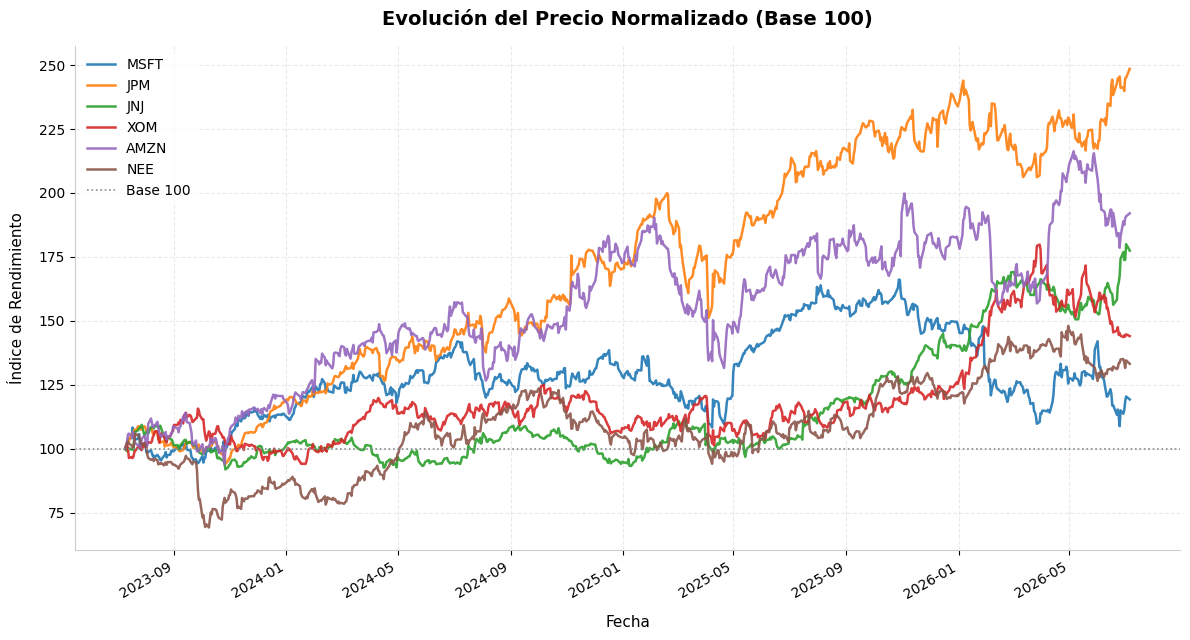

In [6]:
norm = close_df / close_df.iloc[0] * 100

plt.figure(figsize=(12, 6.5))
colors = plt.cm.tab10(range(len(TICKERS)))

for i, t in enumerate(TICKERS):
    plt.plot(norm.index, norm[t], label=t, color=colors[i], lw=1.8, alpha=0.9)

plt.axhline(100, color='#7f8c8d', linestyle=':', lw=1.2, label='Base 100')

plt.title('Evolución del Precio Normalizado (Base 100)', fontweight='bold', fontsize=14, pad=15)
plt.ylabel('Índice de Rendimiento', fontsize=11, labelpad=10)
plt.xlabel('Fecha', fontsize=11, labelpad=10)

ax = plt.gca()
style_ax(ax)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()

plt.legend(frameon=True, facecolor='white', edgecolor='none', loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()


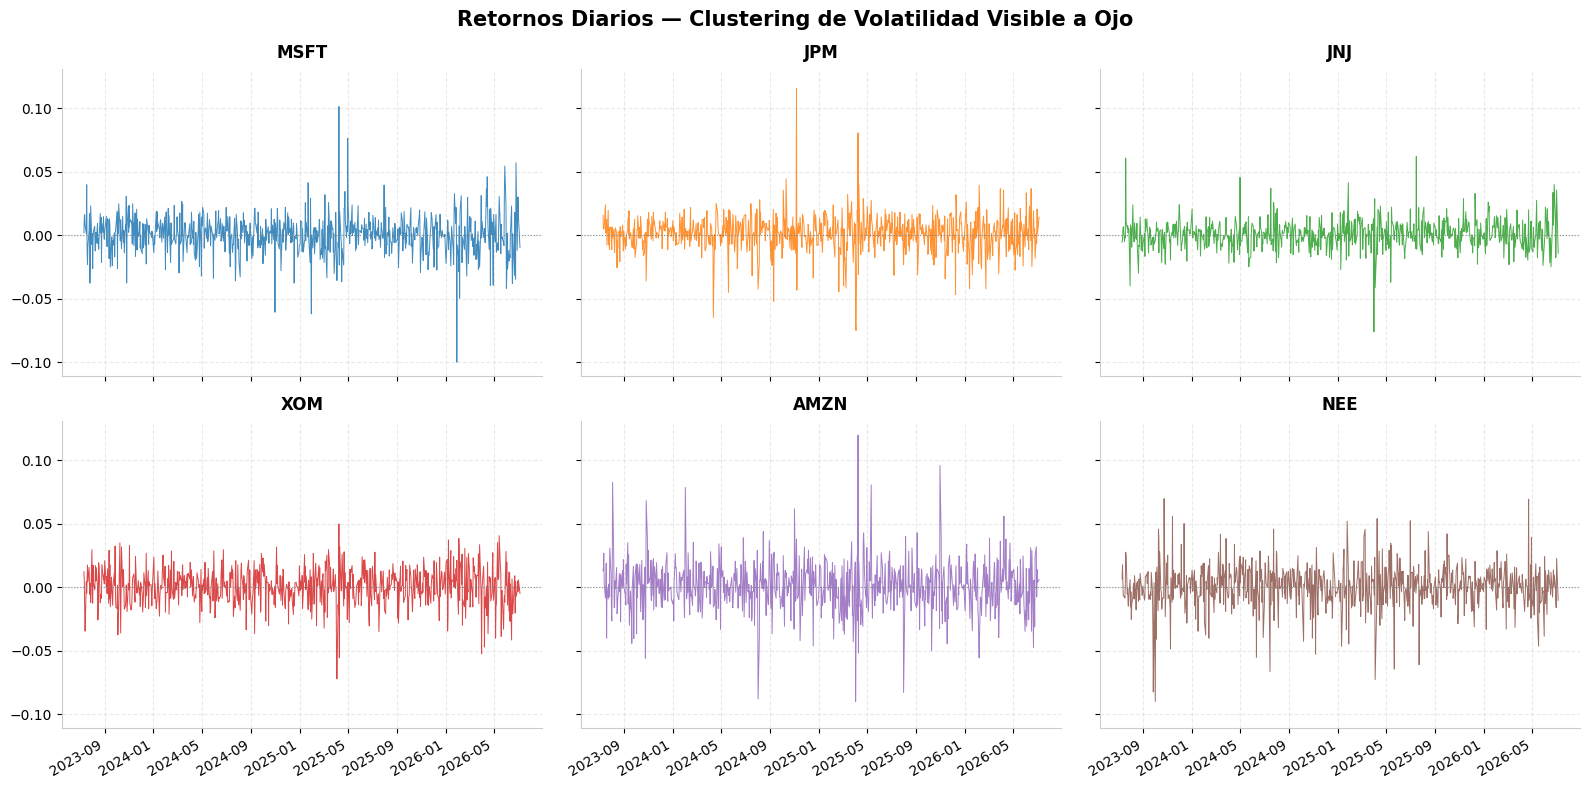

In [7]:
returns_df = close_df.pct_change(fill_method=None).dropna()

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
colors = plt.cm.tab10(range(len(TICKERS)))

for i, (ax, t) in enumerate(zip(axes.flatten(), TICKERS)):
    ax.plot(returns_df.index, returns_df[t], lw=0.7, color=colors[i], alpha=0.85)
    ax.axhline(0, color='#7f8c8d', lw=0.8, linestyle=':')

    ax.set_title(t, fontweight='bold', fontsize=12, pad=8)
    style_ax(ax)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

fig.autofmt_xdate()
plt.suptitle('Retornos Diarios — Clustering de Volatilidad Visible a Ojo', fontweight='bold', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()


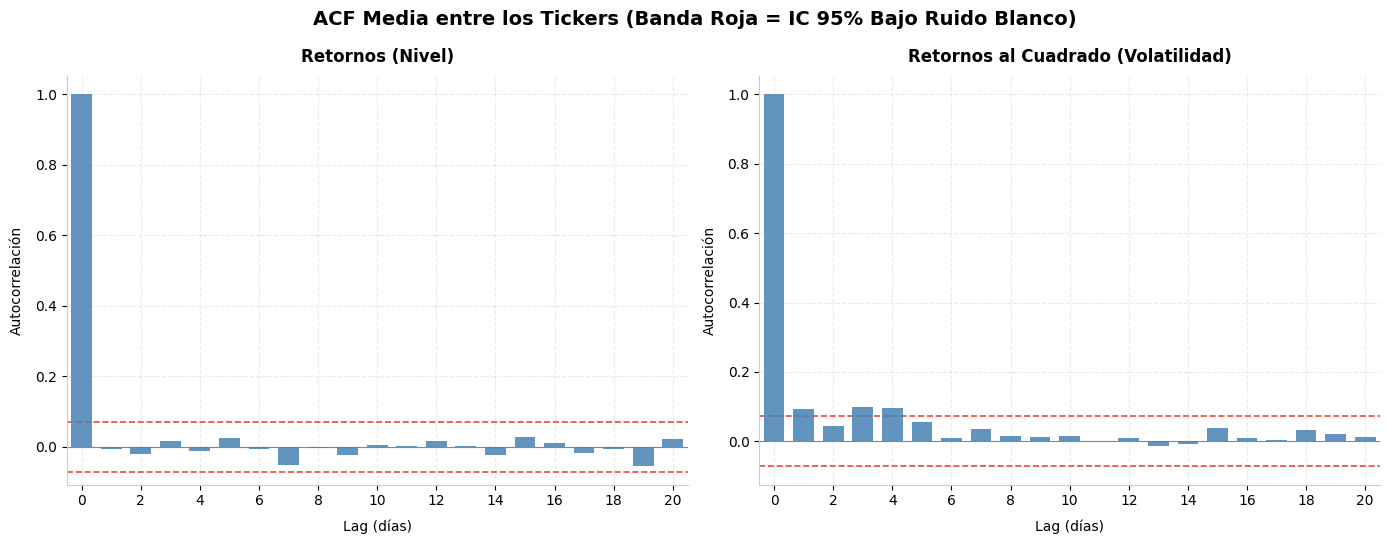

In [8]:
def acf(series, nlags=20):
    x = series.values - series.values.mean()
    n = len(x)
    var = x.var()
    return np.array([1.0 if k == 0 else (x[:n - k] * x[k:]).mean() / var for k in range(nlags + 1)])

nlags = 20
ci = 1.96 / np.sqrt(len(returns_df))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, (title, transform) in zip(axes, [
    ('Retornos (Nivel)', lambda s: s),
    ('Retornos al Cuadrado (Volatilidad)', lambda s: s ** 2),
]):
    avg_acf = np.mean([acf(transform(returns_df[t]), nlags) for t in TICKERS], axis=0)

    ax.bar(range(nlags + 1), avg_acf, color='steelblue', alpha=0.85, width=0.7, zorder=3)

    ax.axhline(ci, color='#e74c3c', linestyle='--', lw=1.2, label='IC 95%')
    ax.axhline(-ci, color='#e74c3c', linestyle='--', lw=1.2)
    ax.axhline(0, color='#7f8c8d', lw=0.8)

    ax.set_title(title, fontweight='bold', fontsize=12, pad=10)
    ax.set_xlabel('Lag (días)', fontsize=10, labelpad=8)
    ax.set_ylabel('Autocorrelación', fontsize=10, labelpad=8)
    ax.set_xlim(-0.5, nlags + 0.5)
    ax.set_xticks(range(0, nlags + 1, 2))
    style_ax(ax)

plt.suptitle('ACF Media entre los Tickers (Banda Roja = IC 95% Bajo Ruido Blanco)', fontweight='bold', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()


## 4 · Modelo TimesFM (zero-shot)

Sin fine-tuning: se usa el checkpoint público `google/timesfm-2.5-200m-pytorch` tal cual. Dos flags relevantes: `infer_is_positive=True` porque la serie forecasteada son **precios** (estrictamente positivos) — el retorno derivado puede ser negativo igualmente, eso no depende de este flag. `force_flip_invariance=False` porque forzar simetría al signo suprimiría el drift del modelo, que es exactamente lo que el backtest quiere medir contra el baseline RW-con-drift.


In [9]:
model = timesfm.TimesFM_2p5_200M_torch.from_pretrained('google/timesfm-2.5-200m-pytorch')
model.compile(timesfm.ForecastConfig(
    max_context=MAX_CONTEXT,
    max_horizon=MAX_HORIZON,
    normalize_inputs=True,
    use_continuous_quantile_head=True,   # banda P10-P90 continua
    force_flip_invariance=False,         # no suprimir el drift del modelo: es parte de lo que se evalua
    infer_is_positive=True,              # la serie forecasteada son precios (> 0)
    fix_quantile_crossing=True,          # garantiza P10 <= P50 <= P90
))


In [10]:
# Columnas de output_quantiles: indice 1..9 -> cuantiles [0.1, 0.2, ..., 0.9] (indice 5 = mediana).
# El indice 0 no es un cuantil (ver timesfm/timesfm_2p5/timesfm_2p5_base.py) y no se usa aqui.
Q10_IDX, Q90_IDX = 1, 9

def forecast_prices(context_df: pd.DataFrame, model, horizon: int = MAX_HORIZON):
    """Forecast de precio por ticker. Devuelve point_forecast (n_tickers, horizon)
    y quantile_forecast (n_tickers, horizon, 10) tal cual los devuelve TimesFM.
    """
    inputs = [context_df[t].values for t in TICKERS]
    point_forecast, quantile_forecast = model.forecast(horizon=horizon, inputs=inputs)
    return point_forecast, quantile_forecast


## 5 · Backtest walk-forward

Origen mínimo a los `MIN_CONTEXT_BACKTEST` días (~1 año) — evaluar con menos contexto sería un escenario que producción, tras el primer año histórico, nunca tendría. A partir de ahí, un origen cada `BACKTEST_STEP` (5) días, hasta dejar sitio para `MAX_HORIZON` días de horizonte real. Los orígenes se solapan con el horizonte mes (21 > 5): ~5× más orígenes (potencia estadística) a cambio de autocorrelación en el diferencial de pérdida — el test DM la corrige con varianza **Newey-West** (lags según el solapamiento) y aplica la corrección de muestra pequeña de **Harvey-Leybourne-Newbold (1997)** con p-valores sobre una t de Student.

Cada origen se evalúa en día 5 (semana) y día 21 (mes) contra **tres** series: TimesFM, random-walk sin drift (retorno esperado 0) y random-walk **con drift** (retorno medio diario del contexto, compuesto al horizonte). El drift es el listón relevante: batir al RW-0 a un mes puede ser únicamente capturar la deriva alcista del mercado.

La evaluación cubre cuatro planos: error puntual (MAE/WAPE/bias + DM), cartera **equal-weight**, calidad de cuantiles (cobertura P10-P90 y pinball loss contra un baseline gaussiano drift+vol del contexto) y acierto direccional (Pesaran-Timmermann) con P&L neto de costes.


In [11]:
def run_backtest(close_df, model, min_context=MIN_CONTEXT_BACKTEST,
                  step=BACKTEST_STEP, max_horizon=MAX_HORIZON, max_context=MAX_CONTEXT):
    """Backtest walk-forward sin fuga: corte por posicion (no por fecha).
    Con step < max_horizon los origenes se solapan — la dependencia resultante
    se corrige en el test DM (Newey-West), no aqui."""
    n = len(close_df)
    origins = list(range(min_context, n - max_horizon, step))

    records = []
    for origin in tqdm(origins, desc='Backtest'):
        context_df = close_df.iloc[max(0, origin - max_context):origin]
        future_df  = close_df.iloc[origin:origin + max_horizon]

        point_fc, quantile_fc = forecast_prices(context_df, model, horizon=max_horizon)

        for i, t in enumerate(TICKERS):
            p0 = context_df[t].iloc[-1]
            r  = context_df[t].pct_change(fill_method=None)
            mu, sigma = r.mean(), r.std()
            for h_name, h in HORIZONS.items():
                records.append({
                    'origin': origin, 'date': close_df.index[origin], 'ticker': t,
                    'horizon': h_name,
                    'actual_ret':       future_df[t].iloc[h - 1] / p0 - 1,
                    'pred_ret_timesfm': point_fc[i][h - 1] / p0 - 1,
                    'pred_ret_rw':      0.0,                  # random walk sin drift
                    'pred_ret_drift':   (1 + mu) ** h - 1,    # random walk con drift historico
                    'pred_ret_q10':     quantile_fc[i][h - 1, Q10_IDX] / p0 - 1,
                    'pred_ret_q90':     quantile_fc[i][h - 1, Q90_IDX] / p0 - 1,
                    'context_sigma':    sigma,
                })

    return pd.DataFrame(records)

if BACKTEST_CACHE.exists():
    bt_df = pd.read_parquet(BACKTEST_CACHE)
    print(f'Cache: {BACKTEST_CACHE}')
else:
    bt_df = run_backtest(close_df, model)
    bt_df.to_parquet(BACKTEST_CACHE)

print(f'Backtest: {bt_df["origin"].nunique()} origenes x {len(TICKERS)} tickers x {len(HORIZONS)} horizontes')


Cache: data/backtest_2026-07-07_step5.parquet
Backtest: 96 origenes x 6 tickers x 2 horizontes


In [12]:
def summarize(df: pd.DataFrame, pred_col: str) -> pd.Series:
    """MAE/WAPE/Bias de un metodo de prediccion. Sin MAPE ni MASE: con retornos
    diarios/semanales cerca de 0, MAPE explota (division por actual~0), y MASE aqui
    seria identico a WAPE porque el baseline (random walk) predice literalmente 0 —
    su error ES el actual, asi que MAE_rw = mean(|actual|) y MASE = WAPE.
    """
    err = df[pred_col] - df['actual_ret']
    return pd.Series({
        'mae':  err.abs().mean(),
        'wape': err.abs().sum() / df['actual_ret'].abs().sum(),
        'bias': err.mean(),
        'n':    len(df),
    })

def build_metrics_df(bt_df: pd.DataFrame, pred_col: str, group_cols=('ticker', 'horizon')) -> pd.DataFrame:
    return bt_df.groupby(list(group_cols)).apply(lambda g: summarize(g, pred_col)).reset_index()

METHODS = ('timesfm', 'rw', 'drift')
metrics = {m: build_metrics_df(bt_df, f'pred_ret_{m}') for m in METHODS}

comparison = metrics['timesfm'].merge(metrics['rw'], on=['ticker', 'horizon'], suffixes=('_timesfm', '_rw'))
comparison = comparison.merge(
    metrics['drift'][['ticker', 'horizon', 'mae']].rename(columns={'mae': 'mae_drift'}),
    on=['ticker', 'horizon'])
comparison['skill_vs_rw']    = 1 - comparison['mae_timesfm'] / comparison['mae_rw']     # >0 => mejor que RW-0
comparison['skill_vs_drift'] = 1 - comparison['mae_timesfm'] / comparison['mae_drift']  # >0 => mejor que RW-drift
comparison[['ticker', 'horizon', 'mae_timesfm', 'mae_rw', 'mae_drift',
            'skill_vs_rw', 'skill_vs_drift', 'bias_timesfm']]


,ticker,horizon,mae_timesfm,mae_rw,mae_drift,skill_vs_rw,skill_vs_drift,bias_timesfm
0,AMZN,mes,0.072327,0.075770,0.074632,0.045431,0.030881,-0.001498
1,AMZN,semana,0.034091,0.034338,0.033885,0.007199,-0.006076,-0.000002
2,JNJ,mes,0.050772,0.048531,0.047560,-0.046176,-0.067520,-0.027805
3,JNJ,semana,0.021210,0.020693,0.020566,-0.024994,-0.031318,-0.007270
4,JPM,mes,0.049359,0.056388,0.056385,0.124646,0.124595,-0.007400
5,JPM,semana,0.024739,0.026299,0.025915,0.059297,0.045369,-0.002517
6,MSFT,mes,0.061175,0.058034,0.061458,-0.054128,0.004601,0.005717
7,MSFT,semana,0.029011,0.027768,0.027895,-0.044766,-0.040003,0.000291
8,NEE,mes,0.047759,0.049860,0.050679,0.042148,0.057632,-0.008645
9,NEE,semana,0.025141,0.025281,0.024705,0.005546,-0.017636,-0.001078


In [13]:
def diebold_mariano(loss_a, loss_b, h_overlap=1):
    """Diebold-Mariano con varianza Newey-West (Bartlett, lags = h_overlap-1) y
    correccion de muestra pequena de Harvey-Leybourne-Newbold (1997); p-valor
    sobre t_{n-1}. h_overlap = ceil(horizonte / step): nº de origenes consecutivos
    cuyas ventanas de forecast se solapan (fuente de autocorrelacion en d).
    Las series deben venir ordenadas por origen."""
    d = np.asarray(loss_a) - np.asarray(loss_b)
    n = len(d)
    dc = d - d.mean()
    K = h_overlap - 1
    var_d = dc @ dc / n
    for k in range(1, K + 1):
        var_d += 2 * (1 - k / (K + 1)) * (dc[:-k] @ dc[k:]) / n
    dm_stat = d.mean() / np.sqrt(max(var_d, 1e-16) / n)
    hln = np.sqrt((n + 1 - 2 * h_overlap + h_overlap * (h_overlap - 1) / n) / n)
    dm_stat *= hln
    p_value = 2 * stats.t.sf(abs(dm_stat), df=n - 1)
    return dm_stat, p_value

H_OVERLAP = {h_name: int(np.ceil(h / BACKTEST_STEP)) for h_name, h in HORIZONS.items()}

dm_records = []
for (ticker, horizon), g in bt_df.groupby(['ticker', 'horizon']):
    g = g.sort_values('origin')
    loss_timesfm = (g['pred_ret_timesfm'] - g['actual_ret']).abs()
    for base in ('rw', 'drift'):
        loss_base = (g[f'pred_ret_{base}'] - g['actual_ret']).abs()
        dm_stat, p_value = diebold_mariano(loss_timesfm, loss_base, H_OVERLAP[horizon])
        dm_records.append({
            'ticker': ticker, 'horizon': horizon, 'baseline': base,
            'dm_stat': dm_stat, 'p_value': p_value,
            'gana_timesfm':  bool(loss_timesfm.mean() < loss_base.mean()),
            'significativo': bool(p_value < 0.05),
        })

dm_df = pd.DataFrame(dm_records)
dm_df


,ticker,horizon,baseline,dm_stat,p_value,gana_timesfm,significativo
0,AMZN,mes,rw,-1.012204,0.314012,True,False
1,AMZN,mes,drift,-0.656050,0.513378,True,False
2,AMZN,semana,rw,-0.374609,0.708786,True,False
3,AMZN,semana,drift,0.303031,0.762528,False,False
4,JNJ,mes,rw,0.850497,0.397187,False,False
5,JNJ,mes,drift,1.025047,0.307944,False,False
6,JNJ,semana,rw,0.711563,0.478479,False,False
7,JNJ,semana,drift,0.858815,0.392604,False,False
8,JPM,mes,rw,-2.133313,0.035476,True,True
9,JPM,mes,drift,-2.145932,0.034427,True,True


### Cuantiles — cobertura y pinball loss

La banda P10-P90 debería contener ~80% de los retornos realizados. Como baseline probabilístico: cuantiles gaussianos paramétricos construidos con el drift y la volatilidad del contexto (`drift ± z·σ·√h`) — lo mínimo que haría cualquier modelo de riesgo básico. Si TimesFM no mejora esto, sus cuantiles tampoco aportan.


In [14]:
def pinball(actual, pred, q):
    diff = np.asarray(actual) - np.asarray(pred)
    return np.mean(np.maximum(q * diff, (q - 1) * diff))

Z10, Z90 = stats.norm.ppf(0.1), stats.norm.ppf(0.9)

q_rows = []
for h_name, g in bt_df.groupby('horizon'):
    h = HORIZONS[h_name]
    scale = g['context_sigma'] * np.sqrt(h)
    gauss_q10 = g['pred_ret_drift'] + Z10 * scale
    gauss_q90 = g['pred_ret_drift'] + Z90 * scale
    q_rows.append({
        'horizon': h_name,
        'cobertura_timesfm': ((g['actual_ret'] >= g['pred_ret_q10']) & (g['actual_ret'] <= g['pred_ret_q90'])).mean(),
        'cobertura_gauss':   ((g['actual_ret'] >= gauss_q10) & (g['actual_ret'] <= gauss_q90)).mean(),
        'pinball_timesfm': (pinball(g['actual_ret'], g['pred_ret_q10'], 0.1)
                            + pinball(g['actual_ret'], g['pred_ret_q90'], 0.9)) / 2,
        'pinball_gauss':   (pinball(g['actual_ret'], gauss_q10, 0.1)
                            + pinball(g['actual_ret'], gauss_q90, 0.9)) / 2,
    })

quantile_eval = pd.DataFrame(q_rows)   # cobertura nominal: 0.80
quantile_eval


,horizon,cobertura_timesfm,cobertura_gauss,pinball_timesfm,pinball_gauss
0,mes,0.748264,0.776042,0.013227,0.013080
1,semana,0.784722,0.802083,0.006345,0.006304


In [15]:
def portfolio_backtest(bt_df: pd.DataFrame, weights: dict) -> pd.DataFrame:
    w = pd.Series(weights)
    ret_cols = ['actual_ret'] + [f'pred_ret_{m}' for m in METHODS]
    rows = []
    for (origin, horizon), g in bt_df.groupby(['origin', 'horizon']):
        g = g.set_index('ticker')
        rows.append({'origin': origin, 'horizon': horizon,
                     **{c: (g[c] * w).sum() for c in ret_cols}})
    return pd.DataFrame(rows)

# Equal-weight, no Max Sharpe: esos pesos estan optimizados sobre esta misma ventana (leakage)
port_bt = portfolio_backtest(bt_df, EQUAL_WEIGHTS)

port_metrics = {m: build_metrics_df(port_bt, f'pred_ret_{m}', group_cols=('horizon',)) for m in METHODS}
port_comparison = port_metrics['timesfm'].merge(port_metrics['rw'], on='horizon', suffixes=('_timesfm', '_rw'))
port_comparison = port_comparison.merge(
    port_metrics['drift'][['horizon', 'mae']].rename(columns={'mae': 'mae_drift'}), on='horizon')
port_comparison['skill_vs_rw']    = 1 - port_comparison['mae_timesfm'] / port_comparison['mae_rw']
port_comparison['skill_vs_drift'] = 1 - port_comparison['mae_timesfm'] / port_comparison['mae_drift']

port_dm_records = []
for horizon, g in port_bt.groupby('horizon'):
    g = g.sort_values('origin')
    loss_timesfm = (g['pred_ret_timesfm'] - g['actual_ret']).abs()
    for base in ('rw', 'drift'):
        loss_base = (g[f'pred_ret_{base}'] - g['actual_ret']).abs()
        dm_stat, p_value = diebold_mariano(loss_timesfm, loss_base, H_OVERLAP[horizon])
        port_dm_records.append({
            'horizon': horizon, 'baseline': base, 'dm_stat': dm_stat, 'p_value': p_value,
            'gana_timesfm':  bool(loss_timesfm.mean() < loss_base.mean()),
            'significativo': bool(p_value < 0.05),
        })
port_dm_df = pd.DataFrame(port_dm_records)

print('CARTERA (equal-weight) — TimesFM vs baselines')
display(port_comparison[['horizon', 'mae_timesfm', 'mae_rw', 'mae_drift',
                         'skill_vs_rw', 'skill_vs_drift', 'bias_timesfm']])
print('\nCARTERA — Diebold-Mariano (Newey-West + HLN)')
display(port_dm_df)


CARTERA (equal-weight) — TimesFM vs baselines


,horizon,mae_timesfm,mae_rw,mae_drift,skill_vs_rw,skill_vs_drift,bias_timesfm
0,mes,0.026334,0.027592,0.024785,0.045601,-0.062510,-0.009733
1,semana,0.013577,0.013508,0.013006,-0.005086,-0.043927,-0.002620



CARTERA — Diebold-Mariano (Newey-West + HLN)


,horizon,baseline,dm_stat,p_value,gana_timesfm,significativo
0,mes,rw,-0.905558,0.367461,True,False
1,mes,drift,0.711334,0.478621,False,False
2,semana,rw,0.231391,0.817509,False,False
3,semana,drift,1.471034,0.144587,False,False


### Direccional y P&L

Hit-rate de signo sobre la cartera equal-weight con test de Pesaran-Timmermann (1992), y P&L de la regla trivial *long si pred > 0, flat si no*, con `COST_BPS` por lado. Con `BACKTEST_STEP=5`, los trades a semana son contiguos sin solapamiento; los de mes se solapan — el retorno medio es por trade, no anualizable directamente.


In [16]:
def pesaran_timmermann(actual, pred):
    """PT (1992): H0 = signo de pred independiente del signo de actual.
    Devuelve (stat, p_value, hit_rate). NaN si pred no varia de signo."""
    a = (np.asarray(actual) > 0).astype(float)
    p = (np.asarray(pred) > 0).astype(float)
    n = len(a)
    hit = float((a == p).mean())
    pa, pp = a.mean(), p.mean()
    p_star = pa * pp + (1 - pa) * (1 - pp)
    v_hat  = p_star * (1 - p_star) / n
    v_star = ((2 * pa - 1) ** 2 * pp * (1 - pp)
              + (2 * pp - 1) ** 2 * pa * (1 - pa)
              + 4 * pa * pp * (1 - pa) * (1 - pp) / n) / n
    if v_hat - v_star <= 0:
        return np.nan, np.nan, hit
    stat = (hit - p_star) / np.sqrt(v_hat - v_star)
    return stat, 2 * (1 - stats.norm.cdf(abs(stat))), hit

cost = 2 * COST_BPS / 1e4   # entrada + salida

dir_rows = []
for h_name, g in port_bt.groupby('horizon'):
    pt_stat, pt_p, hit = pesaran_timmermann(g['actual_ret'], g['pred_ret_timesfm'])
    in_market = g['pred_ret_timesfm'] > 0
    strat_ret = np.where(in_market, g['actual_ret'] - cost, 0.0)
    dir_rows.append({
        'horizon': h_name, 'hit_rate': hit, 'pt_stat': pt_stat, 'pt_p_value': pt_p,
        'ret_medio_estrategia': strat_ret.mean(),
        'ret_medio_buyhold':    g['actual_ret'].mean(),
        'pct_en_mercado':       in_market.mean(),
    })

directional_df = pd.DataFrame(dir_rows)
directional_df


,horizon,hit_rate,pt_stat,pt_p_value,ret_medio_estrategia,ret_medio_buyhold,pct_en_mercado
0,mes,0.531250,-0.620607,0.534858,0.009312,0.013404,0.666667
1,semana,0.510417,-0.622128,0.533857,0.002248,0.003503,0.645833


## 6 · Predicción de cartera (producción)

Este es el código que iría a producción tal cual: un único origen (hoy), contexto = todo el histórico disponible (hasta `MAX_CONTEXT` días), sin nada reservado para comprobar — en producción no existe un "futuro conocido" contra el que contrastar. Aquí sí se usan los pesos Max Sharpe (`WEIGHTS`): son la cartera real, y en producción no hay evaluación que contaminar. Todo lo anterior (secciones 1-5) es el laboratorio que decide si merece la pena confiar en este bloque.


In [17]:
context_df = close_df.iloc[-MAX_CONTEXT:]
point_fc, quantile_fc = forecast_prices(context_df, model)

p0 = context_df.iloc[-1]

prod_forecast = {
    t: {
        'p0':        p0[t],
        'point':     point_fc[i],
        'p10':       quantile_fc[i][:, Q10_IDX],
        'p90':       quantile_fc[i][:, Q90_IDX],
    }
    for i, t in enumerate(TICKERS)
}

port_return = {
    h_name: sum(WEIGHTS[t] * (prod_forecast[t]['point'][h - 1] / prod_forecast[t]['p0'] - 1) for t in TICKERS)
    for h_name, h in HORIZONS.items()
}

print(f'Fecha de origen: {context_df.index[-1].date()}  (contexto: {len(context_df)} dias)')
for h_name, r in port_return.items():
    print(f'Retorno esperado de cartera a {h_name}: {r * 100:+.2f}%')


Fecha de origen: 2026-07-06  (contexto: 750 dias)
Retorno esperado de cartera a semana: +0.04%
Retorno esperado de cartera a mes: -0.89%


## 7 · Visualización

Por ticker: histórico + forecast + banda P10-P90 (válida a nivel de activo individual). A nivel de cartera se muestra solo el retorno esperado puntual (P50 ponderado) — sin banda agregada: sumar bandas P10/P90 ponderadas asumiría correlación perfecta entre activos y sobreestimaría el riesgo de cola de la cartera.


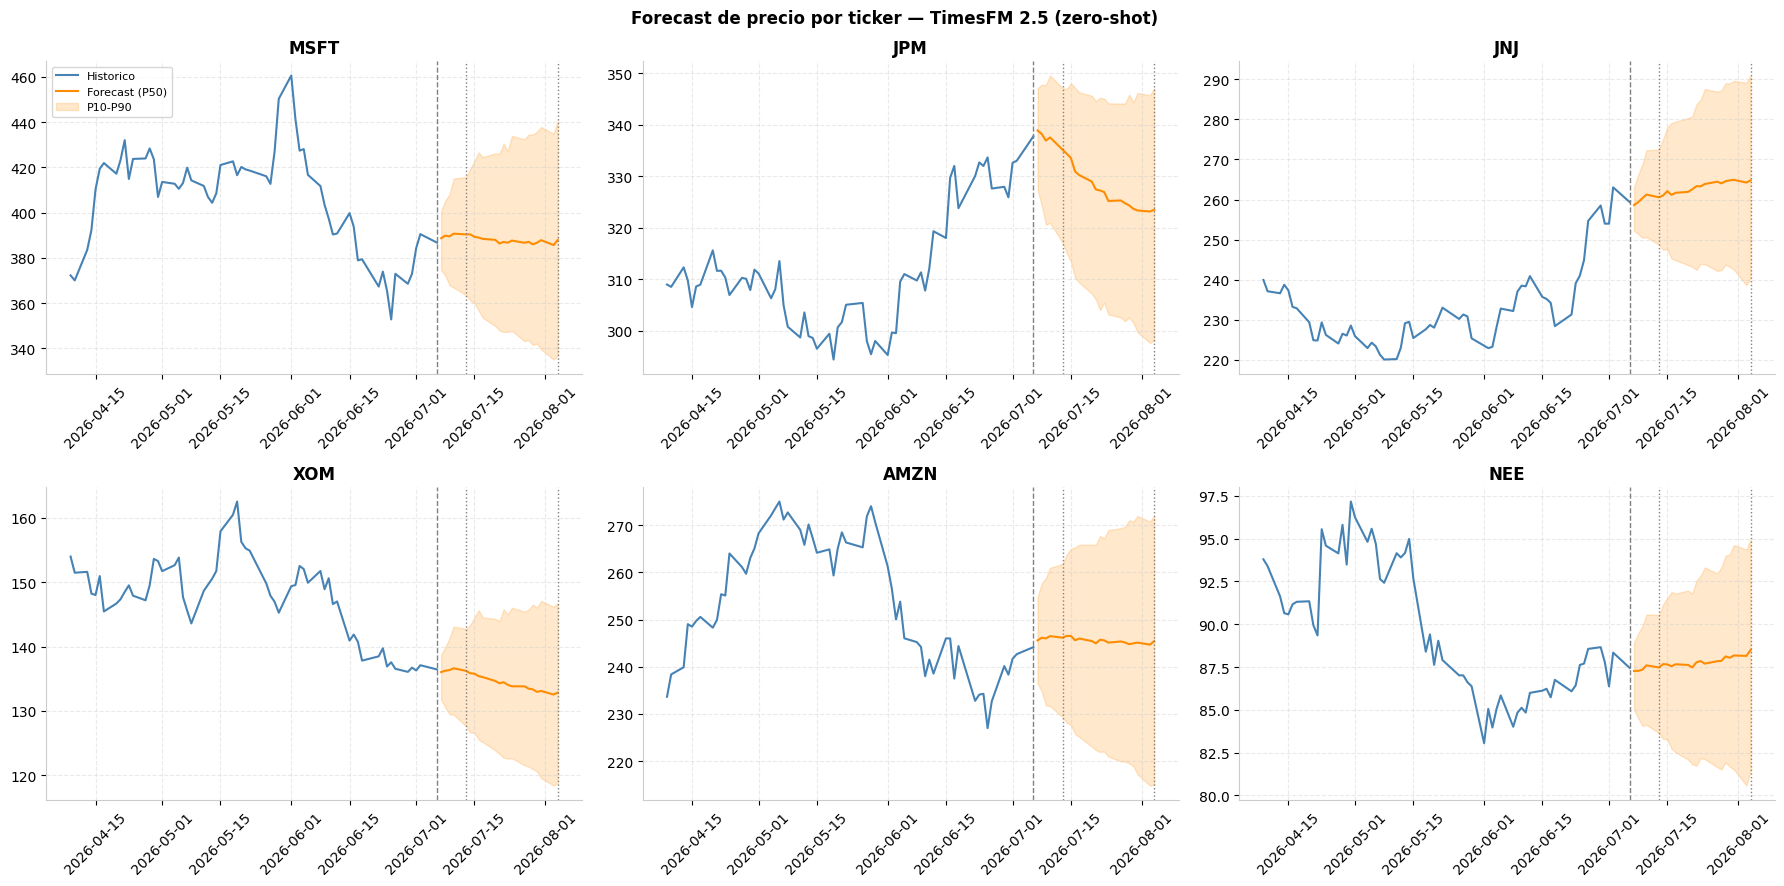

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

future_dates = pd.bdate_range(context_df.index[-1], periods=MAX_HORIZON + 1)[1:]
hist_window  = 60   # dias historicos mostrados, solo para que el chart no quede aplastado

for ax, t in zip(axes.flatten(), TICKERS):
    hist = context_df[t].iloc[-hist_window:]
    ax.plot(hist.index, hist.values, color='steelblue', label='Historico')

    fc = prod_forecast[t]
    ax.plot(future_dates, fc['point'], color='darkorange', label='Forecast (P50)')
    ax.fill_between(future_dates, fc['p10'], fc['p90'], color='darkorange', alpha=0.2, label='P10-P90')
    ax.axvline(context_df.index[-1], color='gray', linestyle='--', lw=1)

    for h_name, h in HORIZONS.items():
        ax.axvline(future_dates[h - 1], color='gray', linestyle=':', lw=1)

    ax.set_title(t, fontweight='bold')
    style_ax(ax)
    ax.tick_params(axis='x', rotation=45)

axes.flatten()[0].legend(loc='upper left', fontsize=8)
plt.suptitle('Forecast de precio por ticker — TimesFM 2.5 (zero-shot)', fontweight='bold')
plt.tight_layout()
plt.show()


## 8 · Conclusiones


In [19]:
print('VEREDICTO DEL BACKTEST (cartera equal-weight, DM Newey-West + HLN)')
print('=' * 70)

for h_name in HORIZONS:
    rows = {b: port_dm_df[(port_dm_df['horizon'] == h_name) & (port_dm_df['baseline'] == b)].iloc[0]
            for b in ('rw', 'drift')}
    pc = port_comparison[port_comparison['horizon'] == h_name].iloc[0]
    print(f'\n[{h_name.upper()}]  skill vs RW-0: {pc["skill_vs_rw"]:+.1%} (p={rows["rw"]["p_value"]:.3f})'
          f'  |  vs RW-drift: {pc["skill_vs_drift"]:+.1%} (p={rows["drift"]["p_value"]:.3f})')
    if all(rows[b]['gana_timesfm'] and rows[b]['significativo'] for b in rows):
        veredicto = 'TimesFM bate a AMBOS baselines con significancia (p<0.05). Senal real a este horizonte.'
    elif rows['drift']['gana_timesfm']:
        veredicto = ('TimesFM gana al RW-con-drift en la muestra pero sin significancia robusta — '
                     'podria ser ruido. No apostar sobre la prediccion de la seccion 6.')
    else:
        veredicto = ('TimesFM NO bate al RW-con-drift: lo que anade sobre capturar la deriva '
                     'historica es cero o negativo. Sin base para confiar en la seccion 6.')
    print(f'  -> {veredicto}')

n_sig_drift = dm_df[(dm_df['baseline'] == 'drift') & dm_df['significativo'] & dm_df['gana_timesfm']].shape[0]
n_comb = dm_df[dm_df['baseline'] == 'drift'].shape[0]
print(f'\nTicker individual (vs RW-drift): {n_sig_drift}/{n_comb} combinaciones ticker-horizonte significativas.')
print('(Con 12 tests al 5% sin correccion por multiplicidad, ~0.6 falsos positivos esperados bajo H0 — no sobreinterpretar victorias aisladas.)')

print('\nCUANTILES — cobertura P10-P90 (nominal 80%) y pinball loss:')
display(quantile_eval)

print('DIRECCIONAL Y P&L (equal-weight, costes incluidos):')
display(directional_df)


VEREDICTO DEL BACKTEST (cartera equal-weight, DM Newey-West + HLN)

[SEMANA]  skill vs RW-0: -0.5% (p=0.818)  |  vs RW-drift: -4.4% (p=0.145)
  -> TimesFM NO bate al RW-con-drift: lo que anade sobre capturar la deriva historica es cero o negativo. Sin base para confiar en la seccion 6.

[MES]  skill vs RW-0: +4.6% (p=0.367)  |  vs RW-drift: -6.3% (p=0.479)
  -> TimesFM NO bate al RW-con-drift: lo que anade sobre capturar la deriva historica es cero o negativo. Sin base para confiar en la seccion 6.

Ticker individual (vs RW-drift): 1/12 combinaciones ticker-horizonte significativas.
(Con 12 tests al 5% sin correccion por multiplicidad, ~0.6 falsos positivos esperados bajo H0 — no sobreinterpretar victorias aisladas.)

CUANTILES — cobertura P10-P90 (nominal 80%) y pinball loss:


,horizon,cobertura_timesfm,cobertura_gauss,pinball_timesfm,pinball_gauss
0,mes,0.748264,0.776042,0.013227,0.013080
1,semana,0.784722,0.802083,0.006345,0.006304


DIRECCIONAL Y P&L (equal-weight, costes incluidos):


,horizon,hit_rate,pt_stat,pt_p_value,ret_medio_estrategia,ret_medio_buyhold,pct_en_mercado
0,mes,0.531250,-0.620607,0.534858,0.009312,0.013404,0.666667
1,semana,0.510417,-0.622128,0.533857,0.002248,0.003503,0.645833
